<a href="https://colab.research.google.com/github/NeonVP31/Statprak/blob/main/dz4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework


Домашним заданием является подготовка отчета для Министерства транспорта, раскрывающего природу и особенности задержек рейсов. Отчет должен помочь выявить проблемные области и способствовать принятию решений. Поэтому старайтесь не излагать общие факты, а показывать проблемы. Например, тот факт, что "средняя задержка вылета составляет 15 минут" сам по себе мало о чем говорит и не помогает понять, почему это происходит. Напротив, график, показывающий, что по понедельникам задержки увеличиваются втрое по сравнению с другими днями на фоне увеличения количества рейсов и пассажиров, наводит на мысль о возможной причине проблемы: аэропорты не справляются с неравномерной загрузкой.

Отчет должен быть оформлен в виде блокнота с четкой структурой. В начале ячейки Markdown есть краткое описание изучаемого вопроса (что мы будем изучать), затем код и все его выходные данные (таблицы, графики, значения), затем снова ячейка Markdown, в которой сформулирован ваш краткий вывод.

Отчет должен содержать не менее 5 результатов, подтвержденных графиками. Для разнообразия материала используйте различные типы диаграмм. Все графики должны быть снабжены необходимыми подписями (обозначения осей, заголовок, цветовая схема).

Для решения задач используйте методы библиотеки pandas.

Из-за того, что загруженность аэропортов неравномерна по дням недели, задержки рейсов и сопутствующие издержки могут возрастать. Исследуем, как меняется среднее время задержки вылета в зависимости от дня недели — это поможет определить дни, когда инфраструктура аэропорта не выдерживает пикового объёма перевозок.

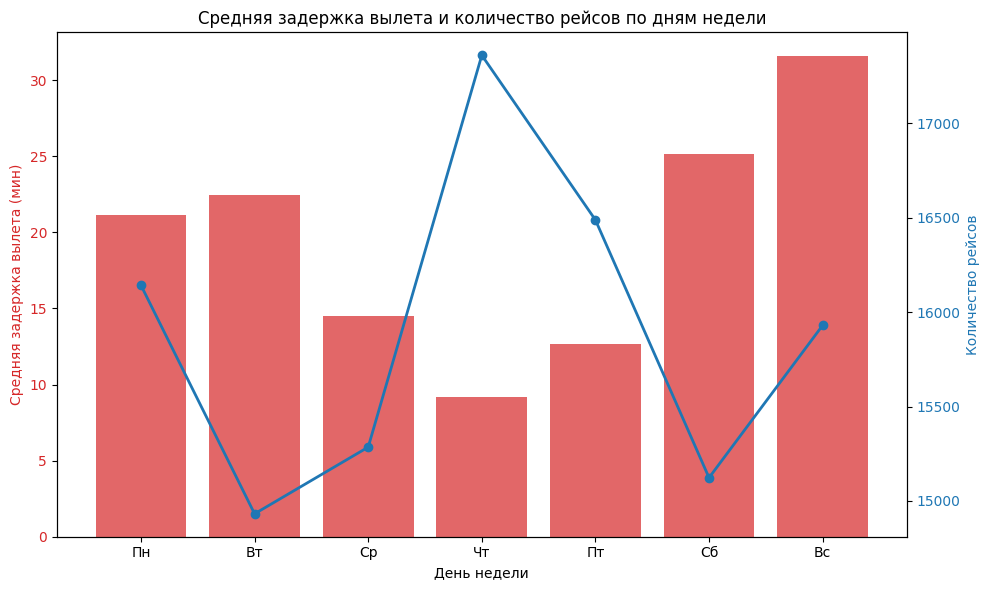

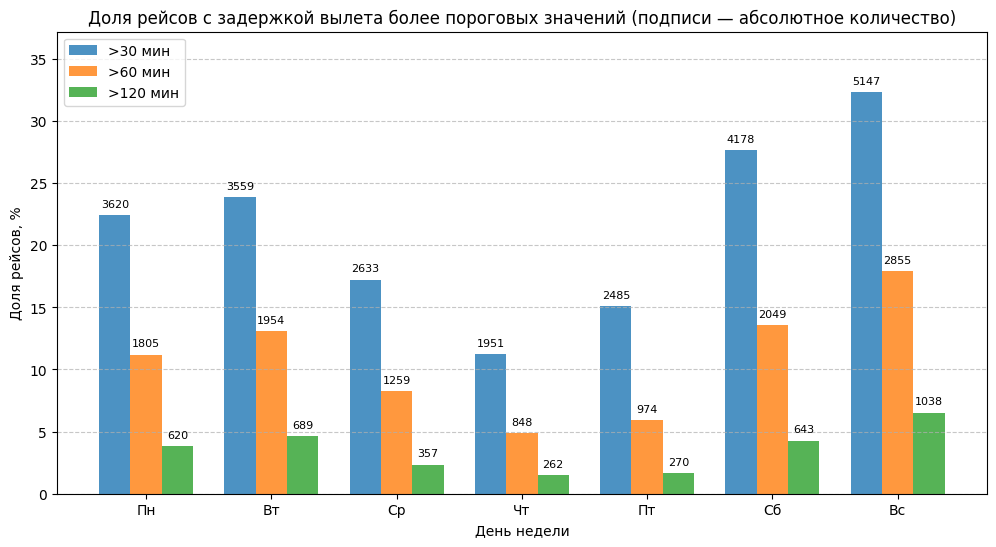

Абсолютное количество рейсов с задержкой более пороговых значений по дням недели:
DAY_LABEL  flight_count  delayed_30  delayed_60  delayed_120
       Пн         16142        3620        1805          620
       Вт         14932        3559        1954          689
       Ср         15285        2633        1259          357
       Чт         17360        1951         848          262
       Пт         16488        2485         974          270
       Сб         15123        4178        2049          643
       Вс         15930        5147        2855         1038


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


flights = pd.read_csv('flights.csv')

# Удалим отменённые или diverted рейсы
flights = flights[flights['DEPARTURE_DELAY'].notna()]

# Преобразование дня недели в читаемый вид (1 = понедельник, 7 = воскресенье)
days_map = {1: 'Пн', 2: 'Вт', 3: 'Ср', 4: 'Чт', 5: 'Пт', 6: 'Сб', 7: 'Вс'}
flights['DAY_OF_WEEK_LABEL'] = flights['DAY_OF_WEEK'].map(days_map)

# Группировка по дню недели: средняя задержка и количество рейсов
delay_by_day = flights.groupby('DAY_OF_WEEK').agg(
    avg_departure_delay=('DEPARTURE_DELAY', 'mean'),
    flight_count=('FLIGHT_NUMBER', 'count')
).reset_index()
delay_by_day['DAY_LABEL'] = delay_by_day['DAY_OF_WEEK'].map(days_map)
delay_by_day = delay_by_day.sort_values('DAY_OF_WEEK')

# Расчёт долей и абсолютных чисел рейсов с задержкой более 30, 60, 120 минут
thresholds = [30, 60, 120]
for thr in thresholds:
    col_name = f'delayed_{thr}'
    # абсолютное значение
    delay_by_day[col_name] = flights.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].apply(
        lambda x: (x > thr).sum()
    ).values
    # проценты
    delay_by_day[f'pct_delay_{thr}'] = delay_by_day[col_name] / delay_by_day['flight_count'] * 100

# первый график (средняя задержка и количество рейсов)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('День недели')
ax1.set_ylabel('Средняя задержка вылета (мин)', color=color)
ax1.bar(delay_by_day['DAY_LABEL'], delay_by_day['avg_departure_delay'], color=color, alpha=0.7, label='Средняя задержка')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Количество рейсов', color=color)
ax2.plot(delay_by_day['DAY_LABEL'], delay_by_day['flight_count'], color=color, marker='o', linewidth=2, label='Количество рейсов')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Средняя задержка вылета и количество рейсов по дням недели')
fig.tight_layout()
plt.show()

# второй график (доля рейсов с задержкой больще порогов)
plt.figure(figsize=(12, 6))
x = np.arange(len(delay_by_day['DAY_LABEL']))
width = 0.25

bars30 = plt.bar(x - width, delay_by_day['pct_delay_30'], width, label='>30 мин', alpha=0.8)
bars60 = plt.bar(x, delay_by_day['pct_delay_60'], width, label='>60 мин', alpha=0.8)
bars120 = plt.bar(x + width, delay_by_day['pct_delay_120'], width, label='>120 мин', alpha=0.8)

# подписи с абсолютными значениями над столбцами
for bars, thr in zip([bars30, bars60, bars120], thresholds):
    for bar, day in zip(bars, delay_by_day['DAY_LABEL']):
        height = bar.get_height()
        abs_val = delay_by_day.loc[delay_by_day['DAY_LABEL'] == day, f'delayed_{thr}'].values[0]
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{abs_val}', ha='center', va='bottom', fontsize=8)

plt.xlabel('День недели')
plt.ylabel('Доля рейсов, %')
plt.title('Доля рейсов с задержкой вылета более пороговых значений (подписи — абсолютное количество)')
plt.xticks(x, delay_by_day['DAY_LABEL'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(delay_by_day['pct_delay_30'])*1.15)  #  место для подписей
plt.show()

print("Абсолютное количество рейсов с задержкой более пороговых значений по дням недели:")
print(delay_by_day[['DAY_LABEL', 'flight_count', 'delayed_30', 'delayed_60', 'delayed_120']].to_string(index=False))
plt.show()

Воскресенье — самый критичный день для перелетов, с максимальным количеством и продолжительностью задержек. При планировании поездок лучше выбирать середину недели (среда-четверг), если есть такая возможность.

Авиакомпаниям следует пересмотреть расписание именно на воскресенье, чтобы повысить пунктуальность и удовлетворенность пассажиров.

